In [42]:

import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


job_data = {
    'job_id': [1, 2, 3, 4, 5],
    'job_title': ['Data Scientist', 'Software Engineer', 'Product Manager', 'Marketing Director', 'HR Manager'],
    'company_name': ['Google', 'Microsoft', 'Apple', 'Nike', 'Starbucks'],
    'job_location': ['Mountain View, CA', 'Redmond, WA', 'Cupertino, CA', 'Beaverton, OR', 'Seattle, WA']
}

company_data = {
    'company_name': ['Google', 'Microsoft', 'Apple', 'Nike', 'Starbucks'],
    'industry': ['Technology', 'Technology', 'Technology', 'Apparel', 'Food & Beverage'],
    'company_size': ['100,000+', '100,000+', '100,000+', '75,000+', '346,000+']
}


df_jobs = pd.DataFrame(job_data)
df_companies = pd.DataFrame(company_data)

In [ ]:
#Merging dataframes
df_jobs.merge(df_companies, on ='company_name')               #Joining dataframes based on company name

,job_id,job_title,company_name,job_location,industry,company_size
0,1,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
1,2,Software Engineer,Microsoft,"Redmond, WA",Technology,"100,000+"
2,3,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"
3,4,Marketing Director,Nike,"Beaverton, OR",Apparel,"75,000+"
4,5,HR Manager,Starbucks,"Seattle, WA",Food & Beverage,"346,000+"


In [ ]:
df_US = df[df['job_country'] == 'United States'].copy()
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')
df_US_pivot = df_US.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')
df_US_pivot = df_US_pivot.reset_index()
df_US_pivot['job_posted_month_no'] = pd.to_datetime(df_US_pivot['job_posted_month'], format='%B').dt.month
df_US_pivot = df_US_pivot.sort_values('job_posted_month_no')
df_US_pivot = df_US_pivot.set_index('job_posted_month')
df_US_pivot = df_US_pivot.drop(columns='job_posted_month_no')

df_US_pivot                         #lots of jobs in software development that I want to compare too



NameError: name 'pdf' is not defined

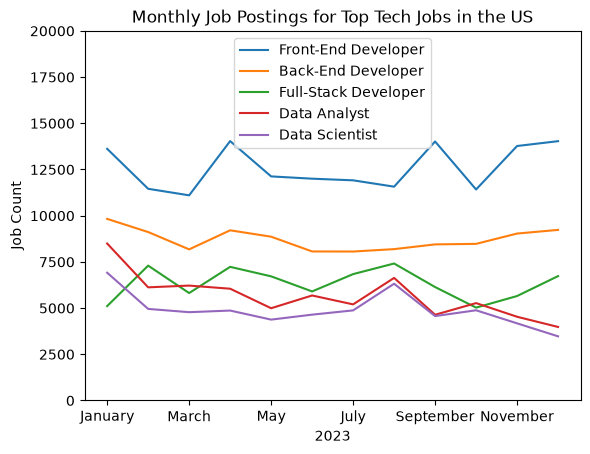

In [17]:
df_US_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col = 'job_posted_month')

df_US_merged = df_US_pivot.merge(df_US_software_pivot, on ='job_posted_month')  #defaulted as inner join

#top 5 jobs based on count

top_5 = df_US_merged.sum().sort_values(ascending = False).head(5).index.to_list()
top_5

df_US_merged[top_5].plot(kind = 'line')
plt.title('Monthly Job Postings for Top Tech Jobs in the US')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.ylim(0,20000)
plt.legend()
plt.show()

In [31]:
# Practice Problems

df_us_jobs = df[df['job_country'] == 'United States']
df['job_posted_month'] = df['job_posted_date'].dt.to_period('M')
df_monthly_postings = df_us_jobs.groupby('job_posted_month').size().reset_index(name='postings_count')
pd.merge(df_us_jobs,df_monthly_postings, on = 'job_posted_month',how = 'right').head(5)

df_not_remote_jobs = df[df['job_work_from_home'] == False]
df_not_remote_salary = df_not_remote_jobs.groupby('job_title_short')['salary_year_avg'].mean().reset_index()
df_not_remote_salary.rename(columns={'salary_year_avg': 'salary_not_remote_avg'}, inplace=True)
pd.merge(df_not_remote_jobs, df_not_remote_salary, on='job_title_short', how='right').head(5)

df_company_salary = df.groupby('company_name')['salary_year_avg'].mean().reset_index()
df_company_remote = df[df['job_work_from_home'] == True].groupby('company_name').size().reset_index(name='remote_count')
pd.merge(df_company_salary, df_company_remote, on='company_name', how='inner').head(5)


,company_name,salary_year_avg,remote_count
0,#EqualsTrue,NaN,4
1,#TeamGoHealth,NaN,1
2,#twiceasnice Recruiting,77750.0,1
3,&Work,NaN,1
4,"(AEG) Application Engineering Group, Inc.",NaN,1


In [ ]:
#Concat dataframe 
 
            
job_postings_jan = pd.DataFrame({
    'job_id': [1, 2, 3, 4, 5],
    'job_title': ['Data Scientist', 'Data Analyst', 'Machine Learning Engineer', 'Data Scientist', 'Data Engineer'],
    'company': ['Company A', 'Company B', 'Company C', 'Company D', 'Company E'],
    'job_posted_date': pd.to_datetime(['2024-01-02', '2024-01-07', '2024-01-14', '2024-01-19', '2024-01-24'])
})
job_postings_feb = pd.DataFrame({
    'job_id': [6, 7, 8, 9, 10],
    'job_title': ['Data Scientist', 'Data Analyst', 'Machine Learning Engineer', 'Data Scientist', 'Data Engineer'],
    'company': ['Company F', 'Company G', 'Company H', 'Company I', 'Company J'],
    'job_posted_date': pd.to_datetime(['2024-02-05', '2024-02-09', '2024-02-12', '2024-02-18', '2024-02-22'])
})
pd.concat([job_postings_jan,job_postings_feb], ingore_index = True)                    #Stacking dataframes on top of each other. Have a list. For index, we can ignore index so it wont repeat




,job_id,job_title,company,job_posted_date
0,1,Data Scientist,Company A,2024-01-02
1,2,Data Analyst,Company B,2024-01-07
2,3,Machine Learning Engineer,Company C,2024-01-14
3,4,Data Scientist,Company D,2024-01-19
4,5,Data Engineer,Company E,2024-01-24
0,6,Data Scientist,Company F,2024-02-05
1,7,Data Analyst,Company G,2024-02-09
2,8,Machine Learning Engineer,Company H,2024-02-12
3,9,Data Scientist,Company I,2024-02-18
4,10,Data Engineer,Company J,2024-02-22


<Axes: xlabel='job_posted_month'>

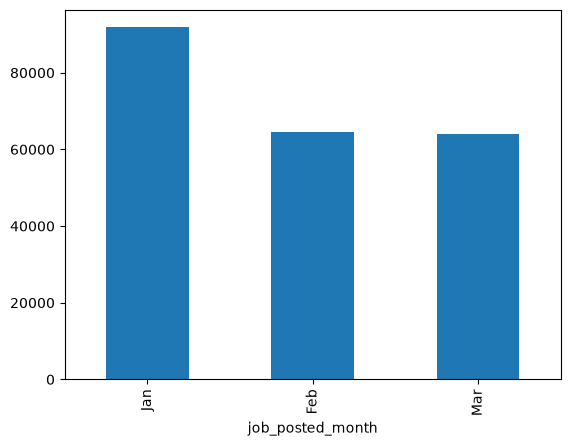

In [39]:
df['job_posted_month'] = df['job_posted_date'].dt.strftime('%b')
# break it up into 12 different dataframes

months = df['job_posted_month'].unique()
months

dict_months = {month: df[df['job_posted_month']== month] for month in months}
dict_months['Jan']

#Needing quarter 1 data

df_q1 = pd.concat([dict_months['Jan'], dict_months['Feb'], dict_months['Mar'] ], ignore_index = True)
df_q1['job_posted_month'].value_counts().plot(kind = 'bar')

In [50]:
# Practice Problems

data_scientist_df = df[df['job_title_short'] == 'Data Scientist']
data_analyst_df = df[df['job_title_short'] == 'Data Analyst']
pd.concat([data_scientist_df, data_analyst_df], ignore_index=True)

oct_df = df[df['job_posted_date'].dt.month == 10]
nov_df = df[df['job_posted_date'].dt.month == 11]
dec_df = df[df['job_posted_date'].dt.month == 12]
pd.concat([oct_df,nov_df,dec_df], ignore_index = True)

full_time_df = df[df['job_schedule_type'] == 'Full-time']
part_time_df = df[df['job_schedule_type'] == 'Part-time']
pd.concat([full_time_df,part_time_df],ignore_index=True)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709603,Data Engineer,Data Engineer*,"Karlsruhe, Germany",via BeBee,Part-time,False,Germany,2023-10-31 06:11:43,False,False,Germany,NaN,NaN,NaN,Robert Bosch Group,"['python', 'sql', 'spark', 'power bi']","{'analyst_tools': ['power bi'], 'libraries': [..."
709604,Senior Data Engineer,Senior Data Engineer,"Porto, Portugal",via BeBee Portugal,Part-time,False,Portugal,2023-10-04 06:16:58,True,False,Portugal,NaN,NaN,NaN,Diconium Digital Solutions,"['python', 'sql', 'java', 'aws', 'azure', 'red...","{'cloud': ['aws', 'azure', 'redshift'], 'libra..."
709605,Data Scientist,"Математик, Junior/Middle/Senior Data Scientist",Anywhere,via Rabota.by,Part-time,True,Belarus,2023-01-30 06:45:28,False,False,Belarus,NaN,NaN,NaN,Представительство ООО «Квалитет» (Российская Ф...,"['python', 'matlab']","{'programming': ['python', 'matlab']}"
709606,Business Analyst,Analyst,Anywhere,via LinkedIn,Part-time,True,India,2023-05-21 06:00:44,False,False,India,NaN,NaN,NaN,Blu Ocean Innovations pvt ltd,NaN,NaN
